In [ ]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image

from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Model

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_path = "D:/SKRIPSI SEMANGADH/DATASET SKRIPSI/skripsilast.v1-last1.folder"


In [3]:
print(os.listdir(dataset_path))

['test', 'train', 'valid']


In [4]:
train_dir = os.path.join(dataset_path, "train")
val_dir   = os.path.join(dataset_path, "valid")
test_dir  = os.path.join(dataset_path, "test")

In [5]:
num_classes = len(os.listdir(train_dir))  # jumlah kelas

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

cnn_features = GlobalAveragePooling2D()(base_model.output)

feature_model = Model(base_model.input, cnn_features)


In [6]:
num_features = feature_model.output_shape
print("Jumlah fitur:", num_features)


Jumlah fitur: (None, 1280)


In [ ]:
# def remove_background_simple(img_np):
#     """
#     img_np: RGB numpy array (H,W,3)
#     return: RGB image dengan background dihitamkan
#     """
#     gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

#     # threshold → sesuaikan nilai 180–220 jika perlu
#     _, mask = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)

#     # operasi morfologi (opsional tapi bagus)
#     kernel = np.ones((3,3), np.uint8)
#     mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

#     img_fg = cv2.bitwise_and(img_np, img_np, mask=mask)
#     return img_fg


In [144]:
# # ============================
# # CEK HASIL MASKING (DEBUG)
# # ============================
# # sample_path = os.path.join(train_dir, os.listdir(train_dir)[0])
# sample_img_name = os.listdir(sample_path)[0]

# img = Image.open(os.path.join(sample_path, sample_img_name)).convert("RGB")
# img = img.resize((224, 224))
# img_np = np.array(img)

# masked = remove_background_simple(img_np)

# plt.figure(figsize=(8,4))

# plt.subplot(1,2,1)
# plt.imshow(img_np)
# plt.title("Original")
# plt.axis("off")

# plt.subplot(1,2,2)
# plt.imshow(masked)
# plt.title("After Masking")
# plt.axis("off")

# plt.show()


In [ ]:
# ============================
# FUNCTION EKSTRAKSI FITUR
# ============================
def extract_features(directory):
    features, labels = [], []
    class_names = sorted(os.listdir(directory))

    for label in class_names:
        folder = os.path.join(directory, label)
        if not os.path.isdir(folder):
            continue

        for filename in tqdm(os.listdir(folder), desc=f"Extracting {label}"):
            img = Image.open(os.path.join(folder, filename)).convert("RGB")
            img = img.resize((224, 224))
            img_np = np.array(img)

            # ===============================
            # BACKGROUND REMOVAL (OPTIONAL)
            # ===============================
            # if use_bg_removal:
            #     img_np = remove_background_simple(img_np)

            arr = preprocess_input(img_np)
            arr = np.expand_dims(arr, 0)

            feat = feature_model.predict(arr, verbose=0)
            features.append(feat[0])
            labels.append(label)

    return np.array(features), np.array(labels)


# ============================
# EKSTRAKSI FITUR
# ============================
X_train, y_train = extract_features(train_dir)
X_val, y_val     = extract_features(val_dir)
X_test, y_test   = extract_features(test_dir)

print("Feature shape before PCA:", X_train.shape)

Extracting SUPER: 100%|██████████| 19/19 [00:03<00:00,  5.84it/s]

Feature shape before PCA: (2205, 1280)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# ============================
# ENCODING LABEL
# ============================
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

#============================
# SCALING
# ============================
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ============================
# PCA REDUCTION
# ============================
pca = PCA(n_components=64)
X_train = pca.fit_transform(X_train_scaled)
X_val   = pca.transform(X_val_scaled)
X_test  = pca.transform(X_test_scaled)

print("After PCA:", X_train.shape)

After PCA: (2205, 64)


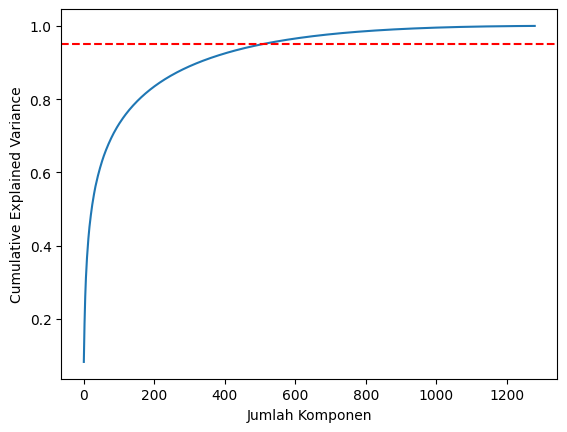

In [147]:
pca_temp = PCA().fit(X_train_scaled)
cum_var = np.cumsum(pca_temp.explained_variance_ratio_)

plt.plot(cum_var)
plt.axhline(0.95, color='r', linestyle='--')
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [ ]:
from sklearn.svm import SVC


svm = SVC(
    C= 10,
    gamma= 'scale',
    kernel= 'rbf',                
    class_weight='balanced', 
    probability=True   
)


svm.fit(X_train, y_train_enc)
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test_enc, y_pred)
print(classification_report(y_test_enc, y_pred))
print("\nTest Accuracy:", round(acc * 100, 2), "%")


              precision    recall  f1-score   support

           0       0.98      1.00      0.99        42
           1       0.97      0.99      0.98        77
           2       1.00      0.96      0.98        55
           3       1.00      1.00      1.00        38

    accuracy                           0.99       212
   macro avg       0.99      0.99      0.99       212
weighted avg       0.99      0.99      0.99       212


Val Accuracy: 98.58 %


In [149]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
# probabilitas tiap kelas
proba_scores = svm.predict_proba(X_test)

# AUC macro
auc_macro = roc_auc_score(y_test_enc, proba_scores, multi_class='ovr', average='macro')

# AUC per class
auc_per_class = roc_auc_score(y_test_enc, proba_scores, multi_class='ovr', average=None)

print("\n=== AUC SCORE ===")
print("AUC Macro:", round(auc_macro, 4))

for cls, score in zip(le.classes_, auc_per_class):
    print(f"AUC {cls}: {round(score, 4)}")


=== AUC SCORE ===
AUC Macro: 1.0
AUC A: 1.0
AUC B: 1.0
AUC DEFECT: 1.0
AUC SUPER: 1.0


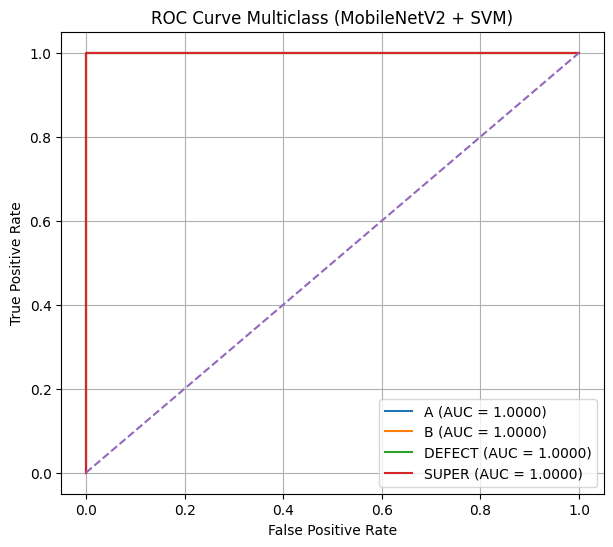

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarisasi label (one-vs-rest)
y_test_bin = label_binarize(y_test_enc, classes=range(len(le.classes_)))

# Ambil probabilitas prediksi
y_score = proba_scores

# Plot ROC curve untuk tiap kelas
plt.figure(figsize=(7, 6))

for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.4f})')

# Garis diagonal (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Multiclass (MobileNetV2 + SVM)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [152]:
#EVALUASI MODEL (TRAINING)
from sklearn.metrics import accuracy_score

# Training accuracy
train_pred = svm.predict(X_train)
train_acc = accuracy_score(y_train_enc, train_pred)
print("Training Accuracy:", train_acc)

Training Accuracy: 1.0


In [153]:
#EVALUASI MODEL (VALIDATION-5 CROSS FOLD)
from sklearn.model_selection import cross_val_score

val_scores = cross_val_score(svm, X_val, y_val_enc, cv=5)

print("Validation Accuracy per fold:", val_scores)
print("Mean Validation Accuracy:", val_scores.mean())


Validation Accuracy per fold: [0.95348837 0.86046512 0.80952381 0.88095238 0.73809524]
Mean Validation Accuracy: 0.8485049833887043


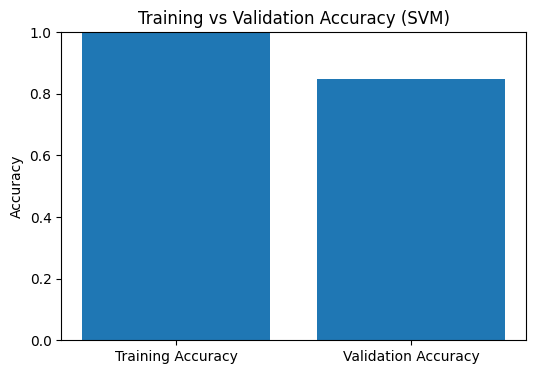

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(["Training Accuracy", "Validation Accuracy"], 
        [train_acc, val_scores.mean()])

plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (SVM)")
plt.ylim(0,1)
plt.show()



=== Classification Report ===
              precision    recall  f1-score   support

           A       0.96      1.00      0.98        26
           B       1.00      1.00      1.00        36
      DEFECT       1.00      1.00      1.00        24
       SUPER       1.00      0.95      0.97        19

    accuracy                           0.99       105
   macro avg       0.99      0.99      0.99       105
weighted avg       0.99      0.99      0.99       105


Test Accuracy: 99.05 %


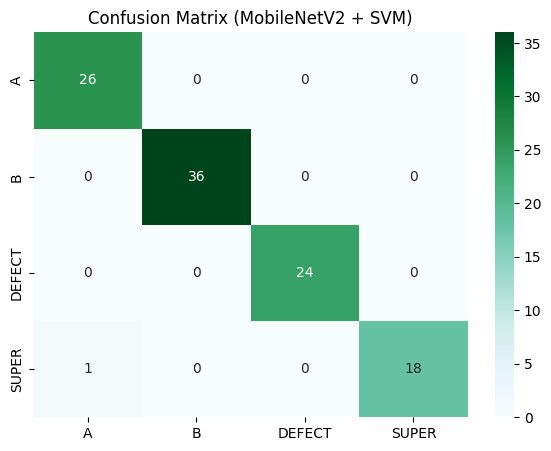

In [155]:
# ============================
# EVALUASI
# ============================
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test_enc, y_pred)

print("\n=== Classification Report ===")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))
print("\nTest Accuracy:", round(acc * 100, 2), "%")

cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix (MobileNetV2 + SVM)")
plt.show()

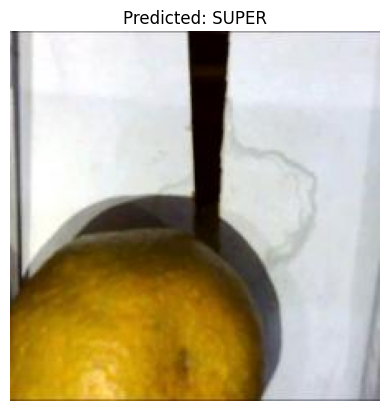

In [156]:
# ============================
# PREDIKSI SINGLE IMAGE
# ============================
test_img_path = "D:/SKRIPSI SEMANGADH/DATASET SKRIPSI/skripshit3.v2-baruv2.folder/test/SUPER/frame06741_png.rf.b7a0a165c039c79e882fdf66846b6e94.jpg"

if os.path.exists(test_img_path):
    img = Image.open(test_img_path).convert("RGB")
    img = img.resize((224, 224))
    arr = preprocess_input(np.array(img))
    arr = np.expand_dims(arr, 0)

    feat = feature_model.predict(arr, verbose=0)
    feat_scaler = scaler.transform(feat)
    feat_pca = pca.transform(feat_scaler)

    pred = svm.predict(feat_pca)[0]
    pred_label = le.inverse_transform([pred])[0]

    plt.imshow(Image.open(test_img_path))
    plt.title(f"Predicted: {pred_label}")
    plt.axis("off")
    plt.show()
else:
    print("Image not found.")

In [157]:
feature_model.save("D:/SKRIPSI SEMANGADH/FILE MODEL/feature_extractor_tes_baruv1_new.h5")

In [158]:
import joblib

save_bundle = {
    # "feature_extract": base_model,
    "scaler": scaler,
    "pca": pca,
    "classifier": svm,
    "classes": le.classes_,
}

save_path = r"D:/SKRIPSI SEMANGADH/FILE MODEL/model_tes_baruv1.pkl"
joblib.dump(save_bundle, save_path)

print("udah ke load bang")

udah ke load bang


In [159]:
from tensorflow.keras.models import load_model

model = load_model("D:/SKRIPSI SEMANGADH/feature_extractor_tes_baruv1_new.h5")
model.summary()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)